Conservative photon-aware PROBA-V reconstruction
Number of LR frames : 6
LR shape            : 128 x 128
HR shape            : (384, 384)
Scale factor        : 3

Estimated frame shifts
------------------------------------------------------------
Frame 00: dx = +0.0000, dy = +0.0000, response = 1.0000
Frame 01: dx = +0.9134, dy = -0.2817, response = 0.7859
Frame 02: dx = -0.0205, dy = -0.1870, response = 0.9570
Frame 03: dx = -0.0547, dy = -0.1805, response = 0.9014
Frame 04: dx = -0.1321, dy = +0.1193, response = 0.3221
Frame 05: dx = -0.0341, dy = -0.2088, response = 0.9539

Blend search
------------------------------------------------------------
alpha = 0.00 | PSNR = 27.3739 dB | SSIM = 0.603090
alpha = 0.10 | PSNR = 27.5031 dB | SSIM = 0.604023
alpha = 0.20 | PSNR = 27.5467 dB | SSIM = 0.591151
alpha = 0.30 | PSNR = 27.5021 dB | SSIM = 0.567101
alpha = 0.40 | PSNR = 27.3719 dB | SSIM = 0.535488
alpha = 0.50 | PSNR = 27.1636 dB | SSIM = 0.499820
alpha = 0.70 | PSNR = 26.5576 dB | S

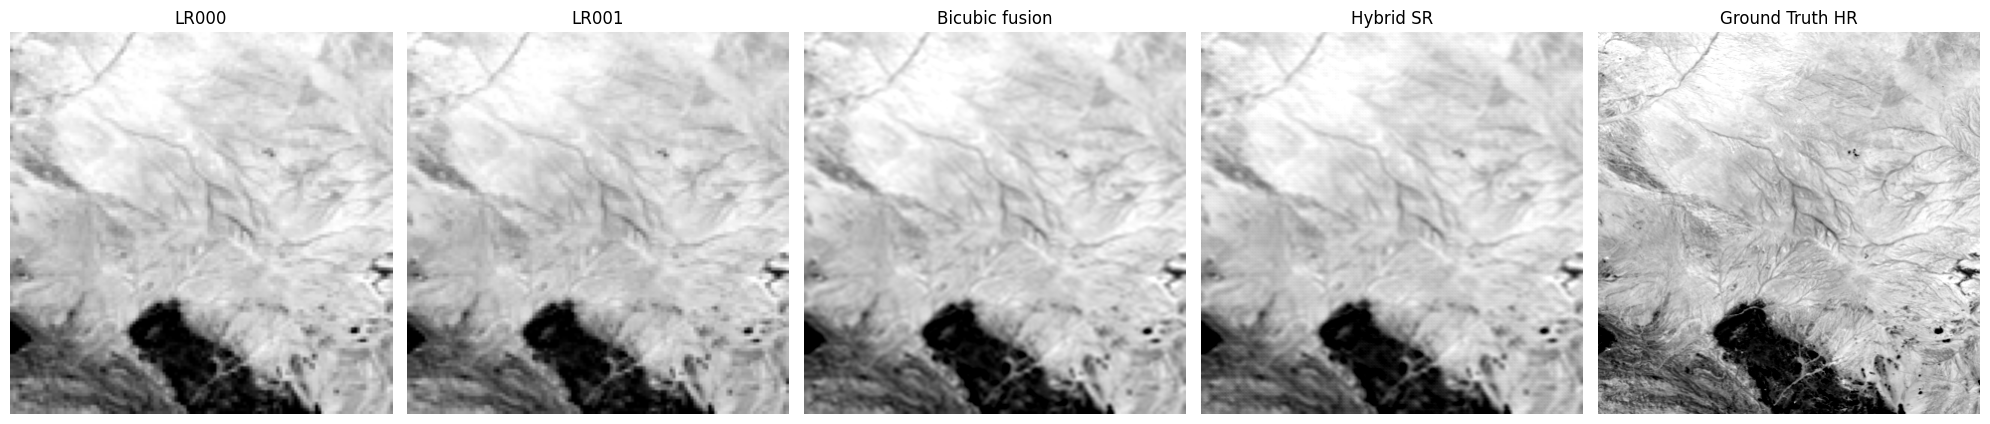

In [10]:
# ============================================================
# CONSERVATIVE PHOTON-AWARE PROBA-V SUPER-RESOLUTION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim


# ============================================================
# 1. FILE PATHS
# ============================================================

LR_FILES = [
    "LR000.png",
    "LR001.png",
    "LR002.png",
    "LR003.png",
    "LR004.png",
    "LR005.png",

    # Add more LR frames if available:
    # "/content/LR002.png",
    # "/content/LR003.png",
]

QM_FILES = [
    "QM000.png",
    "QM001.png",
    "QM002.png",
    "QM003.png",
    "QM004.png",
    "QM005.png",

    # Add corresponding quality maps:
    # "/content/QM002.png",
    # "/content/QM003.png",
]

HR_FILE = "HR.png"


# ============================================================
# 2. SETTINGS
# ============================================================

SCALE = 3

# Try -1 first. If the result is poor, try +1.
SHIFT_SIGN = -1.0

# Use real calibration values here if available.
DN_OFFSET = 0.0
PHOTONS_PER_DN = 1.0

# Approximate detector read noise.
READ_NOISE_PHOTONS = 2.0

# Conservative blending candidates.
BLEND_VALUES = [
    0.00,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.70,
    1.00,
]

# Set this to False when processing data without HR.png.
USE_HR_FOR_SELECTION = True


# ============================================================
# 3. LOAD IMAGES
# ============================================================

def load_gray(path):
    image = cv2.imread(
        path,
        cv2.IMREAD_UNCHANGED
    )

    if image is None:
        raise FileNotFoundError(
            f"Could not load: {path}"
        )

    if image.ndim == 3:
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )

    return image.astype(np.float32)


lr_images = [
    load_gray(path)
    for path in LR_FILES
]

quality_maps = [
    (load_gray(path) > 0).astype(np.float32)
    for path in QM_FILES
]

hr = load_gray(HR_FILE)

if len(lr_images) != len(quality_maps):
    raise ValueError(
        "Each LR image must have one matching quality map."
    )

if len(lr_images) < 2:
    raise ValueError(
        "At least two LR images are required."
    )

H, W = lr_images[0].shape
NUMBER_OF_FRAMES = len(lr_images)

for image in lr_images:
    if image.shape != (H, W):
        raise ValueError(
            "All LR images must have the same shape."
        )

print("=" * 60)
print("Conservative photon-aware PROBA-V reconstruction")
print("=" * 60)
print(f"Number of LR frames : {NUMBER_OF_FRAMES}")
print(f"LR shape            : {H} x {W}")
print(f"HR shape            : {hr.shape}")
print(f"Scale factor        : {SCALE}")


# ============================================================
# 4. CONVERT DN TO PHOTON-LIKE COUNTS
# ============================================================

def convert_to_photons(image):
    """
    Converts DN to photon-like counts.

    The physically correct expression is:

        photons = (DN - offset) * photons_per_DN

    If calibration is unavailable, this is a relative
    photon-like model used for signal-dependent weighting.
    """
    corrected = np.maximum(
        image - DN_OFFSET,
        0.0
    )

    return corrected * PHOTONS_PER_DN


photon_images = [
    convert_to_photons(image)
    for image in lr_images
]


# ============================================================
# 5. PHOTON AND QUALITY WEIGHTS
# ============================================================

def calculate_confidence(photon_image, quality):
    """
    Gives more reliable pixels more influence.

    The weight includes:
    - the quality mask,
    - approximate Poisson noise,
    - detector read noise,
    - a reliability term for very dark pixels.
    """
    variance = (
        np.maximum(photon_image, 1.0)
        + READ_NOISE_PHOTONS ** 2
    )

    inverse_variance = 1.0 / variance

    signal_reliability = photon_image / (
        photon_image
        + READ_NOISE_PHOTONS ** 2
        + 1e-6
    )

    confidence = (
        inverse_variance
        * signal_reliability
        * quality
    )

    return confidence.astype(np.float32)


# ============================================================
# 6. ESTIMATE SUB-PIXEL SHIFTS
# ============================================================

reference = photon_images[0]
reference_quality = quality_maps[0]

window = cv2.createHanningWindow(
    (W, H),
    cv2.CV_32F
)

shifts = [
    (0.0, 0.0)
]

responses = [
    1.0
]

for frame_index in range(1, NUMBER_OF_FRAMES):
    current = photon_images[frame_index]
    current_quality = quality_maps[frame_index]

    reference_for_registration = (
        reference
        * reference_quality
        * window
    )

    current_for_registration = (
        current
        * current_quality
        * window
    )

    measured_shift, response = cv2.phaseCorrelate(
        reference_for_registration,
        current_for_registration
    )

    measured_dx = float(measured_shift[0])
    measured_dy = float(measured_shift[1])

    dx = SHIFT_SIGN * measured_dx
    dy = SHIFT_SIGN * measured_dy

    shifts.append((dx, dy))
    responses.append(float(response))

print("\nEstimated frame shifts")
print("-" * 60)

for index, ((dx, dy), response) in enumerate(
    zip(shifts, responses)
):
    print(
        f"Frame {index:02d}: "
        f"dx = {dx:+.4f}, "
        f"dy = {dy:+.4f}, "
        f"response = {response:.4f}"
    )


# ============================================================
# 7. PHOTON-WEIGHTED HR SPLATTING
# ============================================================

HR_H = H * SCALE
HR_W = W * SCALE

accumulator = np.zeros(
    (HR_H, HR_W),
    dtype=np.float32
)

weight_sum = np.zeros(
    (HR_H, HR_W),
    dtype=np.float32
)


def add_frame_to_hr(
    image,
    quality,
    shift,
    accumulator,
    weight_sum
):
    """
    Places LR pixels on the 3x HR grid using bilinear splatting.
    """
    dx, dy = shift

    y, x = np.indices(
        image.shape,
        dtype=np.float32
    )

    x_hr = (x + dx) * SCALE
    y_hr = (y + dy) * SCALE

    x0 = np.floor(x_hr).astype(np.int32)
    y0 = np.floor(y_hr).astype(np.int32)

    fx = x_hr - x0
    fy = y_hr - y0

    confidence = calculate_confidence(
        image,
        quality
    )

    neighbours = [
        (
            0,
            0,
            (1.0 - fx) * (1.0 - fy)
        ),
        (
            1,
            0,
            fx * (1.0 - fy)
        ),
        (
            0,
            1,
            (1.0 - fx) * fy
        ),
        (
            1,
            1,
            fx * fy
        ),
    ]

    for offset_x, offset_y, interpolation_weight in neighbours:
        xx = x0 + offset_x
        yy = y0 + offset_y

        valid = (
            (confidence > 0.0)
            & (xx >= 0)
            & (xx < HR_W)
            & (yy >= 0)
            & (yy < HR_H)
        )

        local_weight = (
            confidence
            * interpolation_weight
        )

        np.add.at(
            accumulator,
            (yy[valid], xx[valid]),
            image[valid]
            * local_weight[valid]
        )

        np.add.at(
            weight_sum,
            (yy[valid], xx[valid]),
            local_weight[valid]
        )


for image, quality, shift in zip(
    photon_images,
    quality_maps,
    shifts
):
    add_frame_to_hr(
        image,
        quality,
        shift,
        accumulator,
        weight_sum
    )


photon_sr_grid = (
    accumulator
    / np.maximum(weight_sum, 1e-8)
)

# Fill areas that received no observations
missing_pixels = (
    weight_sum <= 1e-8
).astype(np.uint8)

photon_sr_grid = cv2.inpaint(
    photon_sr_grid.astype(np.float32),
    missing_pixels,
    3,
    cv2.INPAINT_TELEA
)

photon_sr_grid = np.maximum(
    photon_sr_grid,
    0.0
)


# ============================================================
# 8. CREATE PHOTON SR IMAGE AT HR SIZE
# ============================================================

photon_sr = cv2.resize(
    photon_sr_grid,
    (hr.shape[1], hr.shape[0]),
    interpolation=cv2.INTER_CUBIC
)

photon_sr = np.maximum(
    photon_sr,
    0.0
)


# ============================================================
# 9. CREATE A STRONG BICUBIC BASELINE
# ============================================================

# Instead of using only LR000, create a quality-weighted
# LR average. This reduces noise before upscaling.

lr_sum = np.zeros_like(
    lr_images[0],
    dtype=np.float32
)

lr_weight_sum = np.zeros_like(
    lr_images[0],
    dtype=np.float32
)

for image, quality in zip(
    photon_images,
    quality_maps
):
    confidence = calculate_confidence(
        image,
        quality
    )

    lr_sum += image * confidence
    lr_weight_sum += confidence

lr_average = (
    lr_sum
    / np.maximum(lr_weight_sum, 1e-8)
)

lr_average = cv2.inpaint(
    lr_average.astype(np.float32),
    (lr_weight_sum <= 1e-8).astype(np.uint8),
    3,
    cv2.INPAINT_TELEA
)

bicubic = cv2.resize(
    lr_average,
    (hr.shape[1], hr.shape[0]),
    interpolation=cv2.INTER_CUBIC
)


# ============================================================
# 10. MATCH THE BRIGHTNESS OF THE SR CANDIDATE
# ============================================================

def match_brightness(source, reference):
    """
    Matches mean and standard deviation of the photon SR
    to the bicubic image before blending.
    """
    source_mean = np.mean(source)
    source_std = np.std(source) + 1e-6

    reference_mean = np.mean(reference)
    reference_std = np.std(reference) + 1e-6

    matched = (
        (source - source_mean)
        * (reference_std / source_std)
        + reference_mean
    )

    return np.maximum(
        matched,
        0.0
    )


photon_sr = match_brightness(
    photon_sr,
    bicubic
)


# ============================================================
# 11. OPTIONAL LIGHT EDGE PRESERVATION
# ============================================================

# This is deliberately weak. Strong sharpening often improves
# appearance but reduces PSNR and SSIM.

smooth = cv2.GaussianBlur(
    photon_sr,
    (0, 0),
    0.6
)

photon_sr = cv2.addWeighted(
    photon_sr,
    1.03,
    smooth,
    -0.03,
    0
)

photon_sr = np.maximum(
    photon_sr,
    0.0
)


# ============================================================
# 12. METRICS
# ============================================================

def calculate_metrics(reference, prediction):
    peak = max(
        float(np.max(reference)),
        1.0
    )

    mse = np.mean(
        (reference - prediction) ** 2
    )

    psnr = 10.0 * np.log10(
        (peak ** 2)
        / max(mse, 1e-12)
    )

    data_range = max(
        float(
            np.max(reference)
            - np.min(reference)
        ),
        1.0
    )

    ssim_value = ssim(
        reference,
        prediction,
        data_range=data_range
    )

    return mse, psnr, ssim_value


# ============================================================
# 13. TEST DIFFERENT BLENDING STRENGTHS
# ============================================================

print("\nBlend search")
print("-" * 60)

best_alpha = 0.0
best_image = bicubic.copy()
best_psnr = -np.inf
best_ssim = -np.inf

for alpha in BLEND_VALUES:
    candidate = (
        (1.0 - alpha) * bicubic
        + alpha * photon_sr
    )

    candidate = np.maximum(
        candidate,
        0.0
    )

    candidate_mse, candidate_psnr, candidate_ssim = (
        calculate_metrics(
            hr,
            candidate
        )
    )

    print(
        f"alpha = {alpha:.2f} | "
        f"PSNR = {candidate_psnr:.4f} dB | "
        f"SSIM = {candidate_ssim:.6f}"
    )

    # Select primarily by SSIM, then PSNR
    if (
        candidate_ssim > best_ssim
        or (
            np.isclose(
                candidate_ssim,
                best_ssim
            )
            and candidate_psnr > best_psnr
        )
    ):
        best_alpha = alpha
        best_image = candidate.copy()
        best_psnr = candidate_psnr
        best_ssim = candidate_ssim


if USE_HR_FOR_SELECTION:
    sr = best_image
else:
    # For real data without HR, use a conservative fixed value.
    # This avoids tuning on the unknown HR target.
    fixed_alpha = 0.20

    sr = (
        (1.0 - fixed_alpha) * bicubic
        + fixed_alpha * photon_sr
    )

    sr = np.maximum(
        sr,
        0.0
    )

    best_alpha = fixed_alpha


# ============================================================
# 14. FINAL EVALUATION
# ============================================================

sr_mse, sr_psnr, sr_ssim = calculate_metrics(
    hr,
    sr
)

bicubic_mse, bicubic_psnr, bicubic_ssim = (
    calculate_metrics(
        hr,
        bicubic
    )
)

photon_mse, photon_psnr, photon_ssim = (
    calculate_metrics(
        hr,
        photon_sr
    )
)

print("\nFinal evaluation")
print("-" * 60)
print(
    f"Photon SR only : "
    f"PSNR = {photon_psnr:.4f} dB, "
    f"SSIM = {photon_ssim:.6f}"
)

print(
    f"Bicubic fusion : "
    f"PSNR = {bicubic_psnr:.4f} dB, "
    f"SSIM = {bicubic_ssim:.6f}"
)

print(
    f"Hybrid output   : "
    f"PSNR = {sr_psnr:.4f} dB, "
    f"SSIM = {sr_ssim:.6f}"
)

print(f"Selected alpha  : {best_alpha:.2f}")


# ============================================================
# 15. CENTRAL-CROP METRICS
# ============================================================

border = 3

hr_crop = hr[
    border:-border,
    border:-border
]

sr_crop = sr[
    border:-border,
    border:-border
]

crop_mse, crop_psnr, crop_ssim = (
    calculate_metrics(
        hr_crop,
        sr_crop
    )
)

print("\nCentral-crop evaluation")
print("-" * 60)
print(f"MSE  : {crop_mse:.4f}")
print(f"PSNR : {crop_psnr:.4f} dB")
print(f"SSIM : {crop_ssim:.6f}")


# ============================================================
# 16. DISPLAY
# ============================================================

def normalize_for_display(image):
    low, high = np.percentile(
        image,
        [2, 98]
    )

    if high <= low:
        return np.zeros_like(image)

    output = (
        image - low
    ) / (high - low)

    return np.clip(
        output,
        0.0,
        1.0
    )


plt.figure(figsize=(20, 6))

plt.subplot(1, 5, 1)
plt.imshow(
    normalize_for_display(lr_images[0]),
    cmap="gray"
)
plt.title("LR000")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(
    normalize_for_display(lr_images[1]),
    cmap="gray"
)
plt.title("LR001")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(
    normalize_for_display(bicubic),
    cmap="gray"
)
plt.title("Bicubic fusion")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(
    normalize_for_display(sr),
    cmap="gray"
)
plt.title("Hybrid SR")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(
    normalize_for_display(hr),
    cmap="gray"
)
plt.title("Ground Truth HR")
plt.axis("off")

plt.tight_layout()
plt.show()